## Reading Annotations

In [ ]:
import json
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

human_annotations_json = '../data/2024-08-01-Face-Count-Posts-Final.json' # @param {type:"string"}

with open(human_annotations_json, 'r') as f:
  j = f.read()
  exported_annotations = json.loads(j)

def process_result(result, coder, md):
    value_type = result.get('type', "")
    metadata = {
        **md,
        "coder": coder,
        "from_name": result.get('from_name', "")
    }
    annotations = []
    if value_type == "choices":
        choices = result['value'].get('choices', [])
        for choice in choices:
            r = {**metadata}
            r['value'] = choice
            annotations.append(r)
    elif value_type == "taxonomy":
        taxonomies = result['value'].get('taxonomy', [])
        for taxonomy in taxonomies:
            if len(taxonomy) > 1:
                taxonomy = " > ".join(taxonomy)
            elif len(taxonomy) == 1:
                taxonomy = taxonomy[0]
            r = {**metadata}
            r['value'] = taxonomy
            annotations.append(r)
    return annotations

all_annotations = []

for data in tqdm(exported_annotations):
    annotations = data.get("annotations")
    metadata = {
        **data.get("data")
    }

    for annotation in annotations:
      coder = annotation['completed_by']['id']
      results = annotation.get("result")
      if results:
        for result in results:
          all_annotations.extend(process_result(result, coder, metadata))
      else:
        print("Skipped Missing Result")


all_annotations_df = pd.DataFrame(all_annotations)

  0%|          | 0/147 [00:00<?, ?it/s]

In [ ]:
all_annotations_df

,name,uuid,image,filename,coder,from_name,value
0,Armin Laschet,1c24a888-95c3-4ccb-8bec-b1fa63390eec,gs://ig-politik-posts/cdu/2021-09-23_10-08-51_...,cdu/2021-09-23_10-08-51_UTC_2.jpg,22199,Crowd,No
1,Armin Laschet,1c24a888-95c3-4ccb-8bec-b1fa63390eec,gs://ig-politik-posts/cdu/2021-09-23_10-08-51_...,cdu/2021-09-23_10-08-51_UTC_2.jpg,22199,PersonCount,ThreeOrMore
2,Armin Laschet,1c24a888-95c3-4ccb-8bec-b1fa63390eec,gs://ig-politik-posts/cdu/2021-09-23_10-08-51_...,cdu/2021-09-23_10-08-51_UTC_2.jpg,7379,Crowd,No
3,Armin Laschet,1c24a888-95c3-4ccb-8bec-b1fa63390eec,gs://ig-politik-posts/cdu/2021-09-23_10-08-51_...,cdu/2021-09-23_10-08-51_UTC_2.jpg,7379,PersonCount,ThreeOrMore
4,Armin Laschet,1c24a888-95c3-4ccb-8bec-b1fa63390eec,gs://ig-politik-posts/cdu/2021-09-23_10-08-51_...,cdu/2021-09-23_10-08-51_UTC_2.jpg,7107,Crowd,No
...,...,...,...,...,...,...,...
875,Olaf Scholz,78d72a2b-d3c2-4b77-994d-1fca1cffc2b1,gs://ig-politik-posts/olafscholz/2021-09-21_13...,olafscholz/2021-09-21_13-38-38_UTC.jpg,22199,PersonCount,OnePerson
876,Olaf Scholz,78d72a2b-d3c2-4b77-994d-1fca1cffc2b1,gs://ig-politik-posts/olafscholz/2021-09-21_13...,olafscholz/2021-09-21_13-38-38_UTC.jpg,7379,Crowd,No
877,Olaf Scholz,78d72a2b-d3c2-4b77-994d-1fca1cffc2b1,gs://ig-politik-posts/olafscholz/2021-09-21_13...,olafscholz/2021-09-21_13-38-38_UTC.jpg,7379,PersonCount,OnePerson
878,Olaf Scholz,78d72a2b-d3c2-4b77-994d-1fca1cffc2b1,gs://ig-politik-posts/olafscholz/2021-09-21_13...,olafscholz/2021-09-21_13-38-38_UTC.jpg,7107,Crowd,No


In [ ]:
from_name = 'PersonCount' # @param {type:"string"}
identifier = 'filename' # @param {type:"string"}

# Assuming your DataFrame is named 'df'
filtered_df = all_annotations_df.copy()
filtered_df = filtered_df[filtered_df['from_name'].str.contains(from_name, case=False)]

def to_bool(val):
  if isinstance(val, bool):
    return val
  if isinstance(val, str):
    return val.lower() == "true"

  return bool(val)

def ls_face_count(n):
    if n == "OnePerson":
      return str(1)
    elif n == "TwoPeople":
      return str(2)
    elif n == "ThreeOrMore":
      return "3+"
    else:
      return "0"

filtered_df['value'] = filtered_df['value'].apply(ls_face_count)
values = filtered_df['value'].unique()
identifier_values = filtered_df[identifier].unique()

contingency_matrix = pd.crosstab(filtered_df[identifier], filtered_df['coder'], values=filtered_df['value'], aggfunc='first')
contingency_matrix = contingency_matrix.reset_index()

In [ ]:
contingency_matrix

coder,filename,7107,7379,22199
0,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,2,2,2
1,abaerbock/2021-09-14_10-00-20_UTC_3.jpg,2,2,2
2,abaerbock/2021-09-17_12-51-57_UTC.jpg,2,2,2
3,abaerbock/2021-09-17_19-48-04_UTC_4.jpg,0,1,1
4,abaerbock/2021-09-19_15-10-45_UTC_2.jpg,3+,3+,3+
...,...,...,...,...
140,spdde/2021-09-16_14-37-13_UTC.jpg,1,1,1
141,spdde/2021-09-17_18-00-10_UTC.jpg,1,1,1
142,spdde/2021-09-18_14-42-04_UTC_7.jpg,2,2,3+
143,spdde/2021-09-24_17-55-02_UTC_2.jpg,2,2,2


Export list of annotations to save money with GPT

In [ ]:
#contingency_matrix.to_csv('../data/2024-07-09-Post-Person-Count-Annotation.csv')
contingency_matrix.to_csv('../data/2024-08-01-Post-Person-Count-Annotation.csv')

## Interrater Agreement

In [ ]:
!pip install -q krippendorff

In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

test_data = contingency_matrix[[7107, 7379, 22199]]  # Nur Katharina und Michael
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.8594207614708753


In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

test_data = contingency_table[[7107, 7379, 'GPT-4o-V3']]  # Nur Katharina und Michael
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha mit GPT-4o-V3:", alpha)

Krippendorff's Alpha mit GPT-4o-V3: 0.8869304086695391


## Majority Decision

In [ ]:
def get_majority_vote(row):
    # Count the votes
    votes = row.dropna().tolist()
    vote_counts = pd.Series(votes).value_counts()

    # Check if there's a clear majority
    if len(vote_counts) == 1 or vote_counts.iloc[0] > vote_counts.iloc[1]:
        return vote_counts.index[0]
    else:
        # If tie or only two votes, use column 7107
        return row[7107]

# Apply the function to each row
contingency_matrix['Gold'] = contingency_matrix.apply(get_majority_vote, axis=1)

In [ ]:
contingency_matrix = contingency_matrix.reset_index()

In [ ]:
contingency_matrix

coder,index,filename,7107,7379,22199,Gold
0,0,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,2,2,2,2
1,1,abaerbock/2021-09-14_10-00-20_UTC_3.jpg,2,2,2,2
2,2,abaerbock/2021-09-17_12-51-57_UTC.jpg,2,2,2,2
3,3,abaerbock/2021-09-17_19-48-04_UTC_4.jpg,0,1,1,1
4,4,abaerbock/2021-09-19_15-10-45_UTC_2.jpg,3+,3+,3+,3+
...,...,...,...,...,...,...
140,140,spdde/2021-09-16_14-37-13_UTC.jpg,1,1,1,1
141,141,spdde/2021-09-17_18-00-10_UTC.jpg,1,1,1,1
142,142,spdde/2021-09-18_14-42-04_UTC_7.jpg,2,2,3+,2
143,143,spdde/2021-09-24_17-55-02_UTC_2.jpg,2,2,2,2


## Evaluation GPT

In [ ]:
gpt_df = pd.read_csv('../data/2024-07-09-Post-Count-Annotation-Not-Sampled-GPT4o-V3.csv')

In [ ]:
contingency_table = pd.merge(contingency_matrix, gpt_df[['Image', "GPT Count"]], left_on="filename", right_on="Image", how='left')
contingency_table.rename(columns={"GPT Count": "GPT-4o-V3"}, inplace=True)

In [ ]:
import re

# Convert entire columns to string type
contingency_table = contingency_table.copy()
contingency_table['GPT-4o-V3'] = contingency_table['GPT-4o-V3'].astype(str)

def repl(input):
  input = input.strip()
  if input == '0':
    return '0'
  if input == '1':
    return '1'
  elif input == '2':
    return '2'
  elif input == '3' or input == '3+':
    return '3+'
  elif int(input) > 3:
    return '3+'
  else:
    return "Problem"

# Apply the regex substitution
contingency_table['GPT-4o-V3'] = contingency_table['GPT-4o-V3'].apply(repl)

In [ ]:
contingency_table.head()

,index,filename,7107,7379,22199,Gold,Image,GPT-4o-V3
0,0,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,2,2,2,2,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,2
1,1,abaerbock/2021-09-14_10-00-20_UTC_3.jpg,2,2,2,2,abaerbock/2021-09-14_10-00-20_UTC_3.jpg,3+
2,2,abaerbock/2021-09-17_12-51-57_UTC.jpg,2,2,2,2,abaerbock/2021-09-17_12-51-57_UTC.jpg,2
3,3,abaerbock/2021-09-17_19-48-04_UTC_4.jpg,0,1,1,1,abaerbock/2021-09-17_19-48-04_UTC_4.jpg,1
4,4,abaerbock/2021-09-19_15-10-45_UTC_2.jpg,3+,3+,3+,3+,abaerbock/2021-09-19_15-10-45_UTC_2.jpg,3+


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from IPython.display import display, Markdown

# Calculating overall metrics
accuracy = accuracy_score(contingency_table['Gold'], contingency_table['GPT-4o-V3'])
precision = precision_score(contingency_table['Gold'], contingency_table['GPT-4o-V3'], average='macro')
recall = recall_score(contingency_table['Gold'], contingency_table['GPT-4o-V3'], average='macro')
f1 = f1_score(contingency_table['Gold'], contingency_table['GPT-4o-V3'], average='macro')

# Creating a DataFrame for the overall metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'GPT': [accuracy, precision, recall, f1]
})

# Displaying the DataFrame as a table
display(Markdown("### Overall Metrics"))
display(metrics_df)

# Generating the classification report for each label
# filter = contingency_table[contingency_table['Gold'] != "0"]
report = classification_report(contingency_table['Gold'], contingency_table['GPT-4o-V3'], output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Displaying the classification report as a table
display(Markdown("### Classification Report for Each Label"))
display(report_df)


### Overall Metrics

,Metric,GPT
0,Accuracy,0.917241
1,Precision,0.929566
2,Recall,0.930742
3,F1 Score,0.929970


### Classification Report for Each Label

,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,1.000000
1,0.969231,0.954545,0.961832,66.000000
2,0.891892,0.868421,0.880000,38.000000
3+,0.857143,0.900000,0.878049,40.000000
accuracy,0.917241,0.917241,0.917241,0.917241
macro avg,0.929566,0.930742,0.929970,145.000000
weighted avg,0.918254,0.917241,0.917537,145.000000


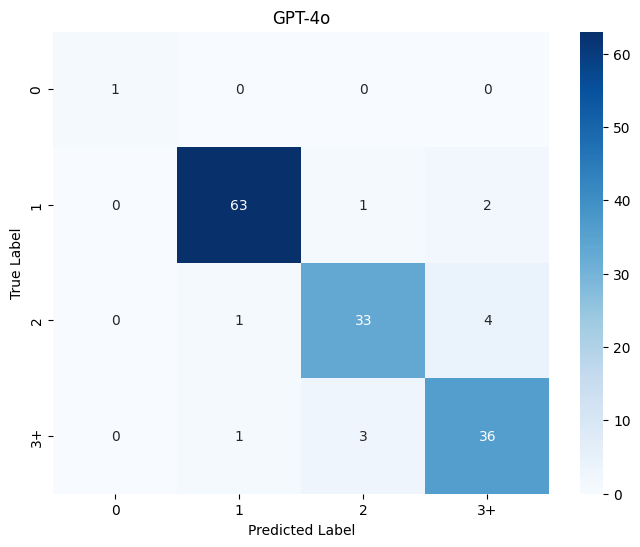

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(contingency_table['Gold'], contingency_table['GPT-4o-V3'])

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(0), str(1), str(2), "3+"], yticklabels=[str(0), str(1), str(2), "3+"])
plt.title('GPT-4o')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

test_data = contingency_table[[7107, 7379, 22199, 'GPT-4o-V3']]  # Nur Katharina und Michael
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.8539316247136797


## Evaluation GPT w/o Crowd

In [ ]:
gpt_wo_df = pd.read_csv('../data/2024-07-09-Post-Count-Annotation-Not-Sampled-GPT4o-V3-wo-crowd.csv')

In [ ]:
contingency_table = pd.merge(contingency_matrix, gpt_wo_df[['Image', "GPT Count"]], left_on="filename", right_on="Image", how='left')
contingency_table.rename(columns={"GPT Count": "GPT-4o-V3-wo"}, inplace=True)

In [ ]:
import re

# Convert entire columns to string type
contingency_table = contingency_table.copy()
contingency_table['GPT-4o-V3-wo'] = contingency_table['GPT-4o-V3-wo'].astype(str)

def repl(input):
  input = input.strip()
  if input == '0':
    return '0'
  if input == '1':
    return '1'
  elif input == '2':
    return '2'
  elif input == '3' or input == '3+':
    return '3+'
  elif int(input) > 3:
    return '3+'
  else:
    return "Problem"

# Apply the regex substitution
contingency_table['GPT-4o-V3-wo'] = contingency_table['GPT-4o-V3-wo'].apply(repl)

In [ ]:
contingency_table.head()

,index,filename,7107,7379,22199,Gold,Image,GPT-4o-V3-wo
0,0,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,2,2,2,2,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,2
1,1,abaerbock/2021-09-14_10-00-20_UTC_3.jpg,2,2,2,2,abaerbock/2021-09-14_10-00-20_UTC_3.jpg,3+
2,2,abaerbock/2021-09-17_12-51-57_UTC.jpg,2,2,2,2,abaerbock/2021-09-17_12-51-57_UTC.jpg,2
3,3,abaerbock/2021-09-17_19-48-04_UTC_4.jpg,0,1,1,1,abaerbock/2021-09-17_19-48-04_UTC_4.jpg,1
4,4,abaerbock/2021-09-19_15-10-45_UTC_2.jpg,3+,3+,3+,3+,abaerbock/2021-09-19_15-10-45_UTC_2.jpg,3+


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from IPython.display import display, Markdown

# Calculating overall metrics
accuracy = accuracy_score(contingency_table['Gold'], contingency_table['GPT-4o-V3-wo'])
precision = precision_score(contingency_table['Gold'], contingency_table['GPT-4o-V3-wo'], average='macro')
recall = recall_score(contingency_table['Gold'], contingency_table['GPT-4o-V3-wo'], average='macro')
f1 = f1_score(contingency_table['Gold'], contingency_table['GPT-4o-V3-wo'], average='macro')

# Creating a DataFrame for the overall metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'GPT': [accuracy, precision, recall, f1]
})

# Displaying the DataFrame as a table
display(Markdown("### Overall Metrics"))
display(metrics_df)

# Generating the classification report for each label
# filter = contingency_table[contingency_table['Gold'] != "0"]
report = classification_report(contingency_table['Gold'], contingency_table['GPT-4o-V3-wo'], output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Displaying the classification report as a table
display(Markdown("### Classification Report for Each Label"))
display(report_df)


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Overall Metrics

,Metric,GPT
0,Accuracy,0.924138
1,Precision,0.685990
2,Recall,0.688317
3,F1 Score,0.686846


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Classification Report for Each Label

,precision,recall,f1-score,support
0,0.000000,0.000000,0.000000,1.000000
1,0.970149,0.984848,0.977444,66.000000
2,0.916667,0.868421,0.891892,38.000000
3+,0.857143,0.900000,0.878049,40.000000
accuracy,0.924138,0.924138,0.924138,0.924138
macro avg,0.685990,0.688317,0.686846,145.000000
weighted avg,0.918268,0.924138,0.920863,145.000000


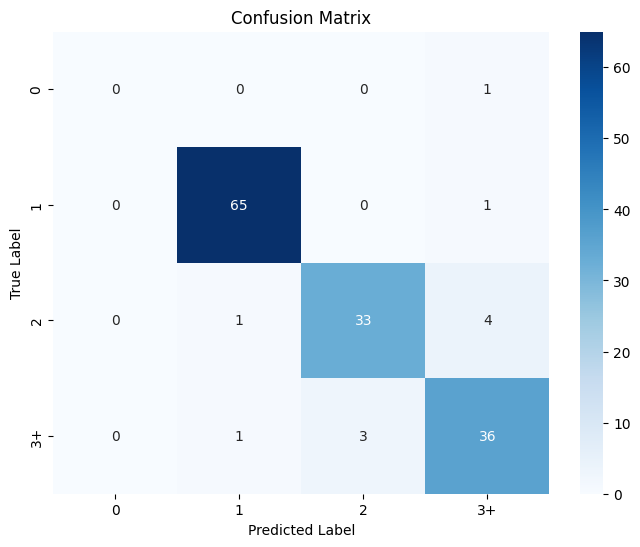

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(contingency_table['Gold'], contingency_table['GPT-4o-V3-wo'])

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(0), str(1), str(2), "3+"], yticklabels=[str(0), str(1), str(2), "3+"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Evaluation Deepface

In [ ]:
deepface_df = pd.read_csv('../data/2024-07-09-Posts-Face-Count-Deepface.csv')

In [ ]:
contingency_table = pd.merge(contingency_table, deepface_df[['filename', "Faces"]], on="filename", how='left')
contingency_table.rename(columns={"Faces": "deepface"}, inplace=True)

In [ ]:
import re

# Convert entire columns to string type
contingency_table = contingency_table.copy()
contingency_table['deepface'] = contingency_table['deepface'].astype(str)

def repl(input):
  input = input.strip()
  if input == '0':
    return '0'
  if input == '1':
    return '1'
  elif input == '2':
    return '2'
  elif input == '3' or input == '3+':
    return '3+'
  elif int(input) > 3:
    return '3+'
  else:
    return "Problem"

# Apply the regex substitution
contingency_table['deepface'] = contingency_table['deepface'].apply(repl)

In [ ]:
contingency_table.head()

,index,filename,7107,7379,22199,Gold,Image,GPT-4o-V3-wo,deepface
0,0,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,2,2,2,2,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,2,2
1,1,abaerbock/2021-09-14_10-00-20_UTC_3.jpg,2,2,2,2,abaerbock/2021-09-14_10-00-20_UTC_3.jpg,3+,3+
2,2,abaerbock/2021-09-17_12-51-57_UTC.jpg,2,2,2,2,abaerbock/2021-09-17_12-51-57_UTC.jpg,2,2
3,3,abaerbock/2021-09-17_19-48-04_UTC_4.jpg,0,1,1,1,abaerbock/2021-09-17_19-48-04_UTC_4.jpg,1,3+
4,4,abaerbock/2021-09-19_15-10-45_UTC_2.jpg,3+,3+,3+,3+,abaerbock/2021-09-19_15-10-45_UTC_2.jpg,3+,3+


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from IPython.display import display, Markdown

# Calculating overall metrics
accuracy = accuracy_score(contingency_table['Gold'], contingency_table['deepface'])
precision = precision_score(contingency_table['Gold'], contingency_table['deepface'], average='macro')
recall = recall_score(contingency_table['Gold'], contingency_table['deepface'], average='macro')
f1 = f1_score(contingency_table['Gold'], contingency_table['deepface'], average='macro')

# Creating a DataFrame for the overall metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'GPT': [accuracy, precision, recall, f1]
})

# Displaying the DataFrame as a table
display(Markdown("### Overall Metrics"))
display(metrics_df)

# Generating the classification report for each label
# filter = contingency_table[contingency_table['Gold'] != "0"]
report = classification_report(contingency_table['Gold'], contingency_table['deepface'], output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Displaying the classification report as a table
display(Markdown("### Classification Report for Each Label"))
display(report_df)


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Overall Metrics

,Metric,GPT
0,Accuracy,0.724138
1,Precision,0.551071
2,Recall,0.542185
3,F1 Score,0.530084


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Classification Report for Each Label

,precision,recall,f1-score,support
0,0.000000,0.000000,0.000000,1.000000
1,0.960784,0.742424,0.837607,66.000000
2,0.689655,0.526316,0.597015,38.000000
3+,0.553846,0.900000,0.685714,40.000000
accuracy,0.724138,0.724138,0.724138,0.724138
macro avg,0.551071,0.542185,0.530084,145.000000
weighted avg,0.770845,0.724138,0.726877,145.000000


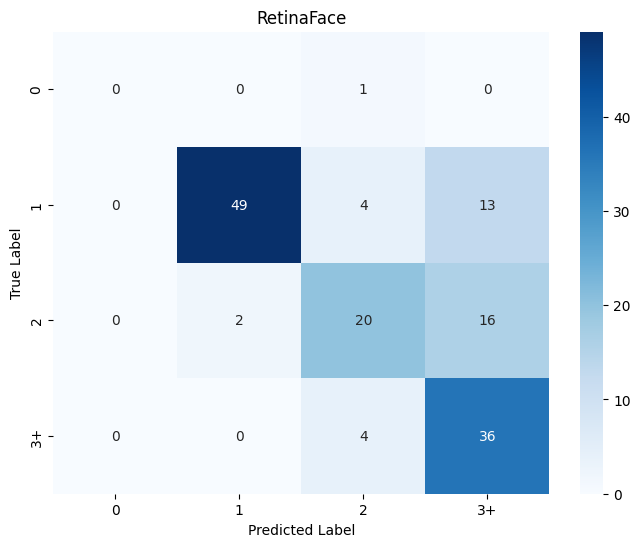

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(contingency_table['Gold'], contingency_table['deepface'])

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(0), str(1), str(2), "3+"], yticklabels=[str(0), str(1), str(2), "3+"])
plt.title('RetinaFace')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

test_data = contingency_table[[7107, 7379, 22199, 'deepface']]  # Nur Katharina und Michael
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.7338940418650235


## Evaluation Google Cloud Vision

In [ ]:
gcv_df = pd.read_csv('../data/2024-07-07-Post-Google-Cloud-Vision-Object-Detection.csv')

In [ ]:
contingency_table = contingency_matrix.copy()

In [ ]:
def count_people(row):
    o = gcv_df[gcv_df['image'] == row['filename']]
    o = o[o['object_name'] == "Person"]
    # Get value counts of object_name
    object_counts = o['object_name'].value_counts()

    if len(object_counts) == 1:
      return object_counts[0]
    else:
      return 0

contingency_table['GCV'] = contingency_table.apply(count_people, axis=1)

<ipython-input-39-d364fd61c692>:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return object_counts[0]
<ipython-input-39-d364fd61c692>:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return object_counts[0]
<ipython-input-39-d364fd61c692>:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return object_counts[0]
<ipython-input-39-d364fd61c692>:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur

In [ ]:
def int_to_str(n):
  if n < 3:
    return str(n)
  elif n >= 3:
    return "3+"
  else:
    return "Problem"

In [ ]:
contingency_table['GCV'] = contingency_table['GCV'].apply(int_to_str)

In [ ]:
contingency_table.head()

coder,index,filename,7107,7379,22199,Gold,GCV
0,0,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,2,2,2,2,2
1,1,abaerbock/2021-09-14_10-00-20_UTC_3.jpg,2,2,2,2,3+
2,2,abaerbock/2021-09-17_12-51-57_UTC.jpg,2,2,2,2,3+
3,3,abaerbock/2021-09-17_19-48-04_UTC_4.jpg,0,1,1,1,3+
4,4,abaerbock/2021-09-19_15-10-45_UTC_2.jpg,3+,3+,3+,3+,3+


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from IPython.display import display, Markdown

# Calculating overall metrics
accuracy = accuracy_score(contingency_table['Gold'], contingency_table['GCV'])
precision = precision_score(contingency_table['Gold'], contingency_table['GCV'], average='macro')
recall = recall_score(contingency_table['Gold'], contingency_table['GCV'], average='macro')
f1 = f1_score(contingency_table['Gold'], contingency_table['GCV'], average='macro')

# Creating a DataFrame for the overall metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'GPT': [accuracy, precision, recall, f1]
})

# Displaying the DataFrame as a table
display(Markdown("### Overall Metrics"))
display(metrics_df)

# Generating the classification report for each label
# filter = contingency_table[contingency_table['Gold'] != "0"]
report = classification_report(contingency_table['Gold'], contingency_table['GCV'], output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Displaying the classification report as a table
display(Markdown("### Classification Report for Each Label"))
display(report_df)


### Overall Metrics

,Metric,GPT
0,Accuracy,0.510345
1,Precision,0.487729
2,Recall,0.639613
3,F1 Score,0.436630


### Classification Report for Each Label

,precision,recall,f1-score,support
0,0.200000,1.000000,0.333333,1.000000
1,1.000000,0.424242,0.595745,66.000000
2,0.333333,0.184211,0.237288,38.000000
3+,0.417582,0.950000,0.580153,40.000000
accuracy,0.510345,0.510345,0.510345,0.510345
macro avg,0.487729,0.639613,0.436630,145.000000
weighted avg,0.659103,0.510345,0.495693,145.000000


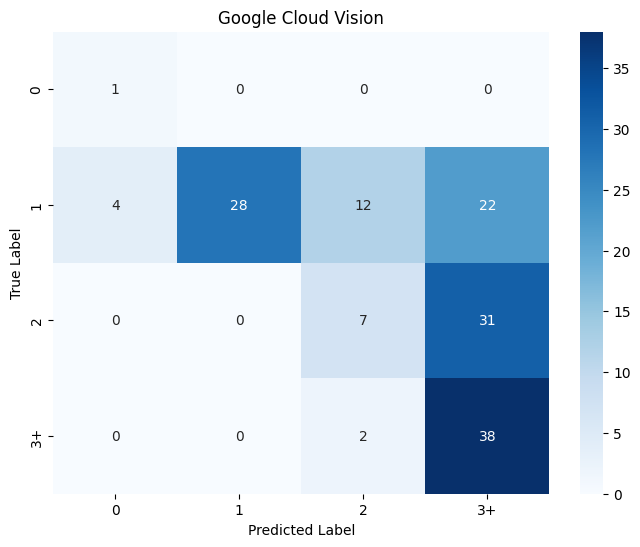

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(contingency_table['Gold'], contingency_table['GCV'])

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(0), str(1), str(2), "3+"], yticklabels=[str(0), str(1), str(2), "3+"])
plt.title('Google Cloud Vision')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

test_data = contingency_table[[7107, 7379, 22199, 'GCV']]  # Nur Katharina und Michael
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.5735940879596251
